<a href="https://colab.research.google.com/github/shreeraj-chatterjee/financial-fraud-classification/blob/main/notebooks/gat_focal_loss_fraud_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Check if GPU is available

In [ ]:
import torch
print(torch.cuda.is_available())

True


Define the device (Output should be: cuda)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Run this once per session (Access to my Google Drive)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 1: Install Dependencies
# We can rely on Colab's pre-installed PyTorch and just install torch-geometric directly.
!pip install torch-geometric scikit-learn matplotlib pandas
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 52.1 MB/s eta 0:00:00


In [ ]:
# Cell 2: Data Loading and Preprocessing
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/creditcard.csv')

print("Original Dataset Shape:", df.shape)
print("Fraudulent transactions:", len(df[df['Class'] == 1]))
print("Legitimate transactions:", len(df[df['Class'] == 0]))

# Separate features and labels
# We drop 'Time', 'Class' as they aren't predictive features in the same way
features = df.drop(columns=['Time', 'Class']).values
labels = df['Class'].values

# Standardize features (Mean = 0, Variance = 1)
scaler = StandardScaler()
features = scaler.fit_transform(features)

# Convert to PyTorch tensors
X = torch.tensor(features, dtype=torch.float32).to(device)
y = torch.tensor(labels, dtype=torch.long).to(device)

print("Feature Tensor Shape:", X.shape)
print("Label Tensor Shape:", y.shape)

Original Dataset Shape: (284807, 31)
Fraudulent transactions: 492
Legitimate transactions: 284315
Feature Tensor Shape: torch.Size([284807, 29])
Label Tensor Shape: torch.Size([284807])


In [ ]:
# Cell 3: Graph Construction
import faiss
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

def create_knn_edge_index(X_np, k=5):
    print(f"Building KNN graph with k={k} using FAISS (CPU)...")

    X_np = np.ascontiguousarray(X_np, dtype=np.float32)

    d = X_np.shape[1]

    # Use CPU index directly
    index = faiss.IndexFlatL2(d)
    index.add(X_np)

    distances, indices = index.search(X_np, k + 1)

    neighbors = indices[:, 1:]

    num_nodes = X_np.shape[0]
    rows = np.repeat(np.arange(num_nodes), k)
    cols = neighbors.flatten()

    edge_index = torch.tensor(np.vstack((rows, cols)), dtype=torch.long)
    edge_index = to_undirected(edge_index).to(device)

    return edge_index

# Create the edge index using the numpy version of our features
edge_index = create_knn_edge_index(features, k=5)

# Create the PyTorch Geometric Data object
data = Data(x=X, edge_index=edge_index, y=y)

print("\nGraph Conversion Successful!")
print(f"Number of Nodes (Transactions): {data.num_nodes}")
print(f"Number of Edges (Connections): {data.num_edges}")

Building KNN graph with k=5 using FAISS (CPU)...

Graph Conversion Successful!
Number of Nodes (Transactions): 284807
Number of Edges (Connections): 2030677


In [ ]:
# Cell 4: Define and Initialize the GNN Model
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
import torch.nn as nn
import torch.optim as optim

class GAT_FraudModel(nn.Module):
    def __init__(self, in_features, hidden_dim, out_features, heads=4, dropout_rate=0.5):
        super(GAT_FraudModel, self).__init__()
        self.conv1 = GATConv(in_features, hidden_dim, heads=heads, dropout=dropout_rate)
        self.conv2 = GATConv(hidden_dim * heads, out_features, heads=1, concat=False, dropout=dropout_rate)
        self.dropout_rate = dropout_rate

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

num_features = X.shape[1]
num_classes = 2

model = GAT_FraudModel(
    in_features=num_features,
    hidden_dim=8,
    out_features=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

# alpha=0.75 gives slightly more weight to the fraud class without overwhelming the model
criterion = FocalLoss(alpha=0.75, gamma=2.0)

print(model)
print(f"Model successfully moved to: {device}")

GAT_FraudModel(
  (conv1): GATConv(29, 8, heads=4)
  (conv2): GATConv(32, 2, heads=1)
)
Model successfully moved to: cuda


## Model Training and Evaluation Results

Starting Training...
Epoch 10/50, Train Loss: 0.0595, Test Loss: 0.0431
Epoch 20/50, Train Loss: 0.0274, Test Loss: 0.0130
Epoch 30/50, Train Loss: 0.0189, Test Loss: 0.0065
Epoch 40/50, Train Loss: 0.0153, Test Loss: 0.0049
Epoch 50/50, Train Loss: 0.0139, Test Loss: 0.0043

--- Final Test Set Results ---
Accuracy: 0.9992
Precision: 0.7404
Recall: 0.7857
F1 Score: 0.7624
AUC-ROC Score: 0.9615


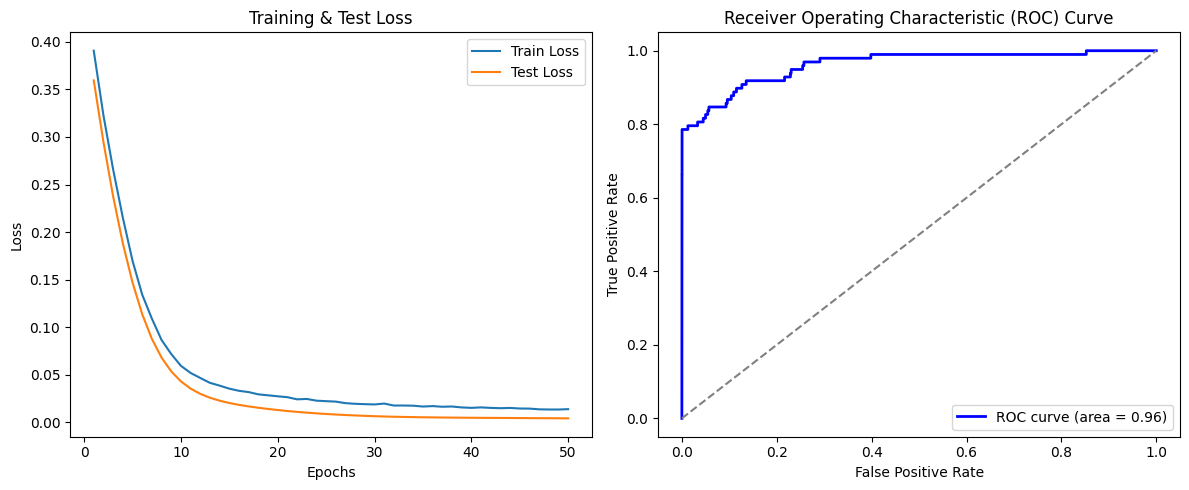

In [ ]:
# Cell 5: Training the GNN and Evaluating Performance

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Create Train/Test Masks
# We split the indices: 80% for training, 20% for testing
train_indices, test_indices = train_test_split(
    np.arange(data.num_nodes),
    test_size=0.2,
    random_state=42,
    stratify=data.y.cpu().numpy() # Ensure equal ratio of fraud in both sets
)

# Convert masks to PyTorch tensors and move them to the GPU
train_mask = torch.tensor(train_indices, dtype=torch.long).to(device)
test_mask = torch.tensor(test_indices, dtype=torch.long).to(device)

# 2. Train the Model
epochs = 50
train_losses = []
test_losses = []

print("Starting Training...")
for epoch in range(epochs):
    model.train()           # Set model to training mode
    optimizer.zero_grad()   # Clear old gradients

    out = model(data)       # Forward pass: get predictions for all nodes

    # Calculate loss ONLY on the training nodes
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()         # Backward pass: calculate gradients
    optimizer.step()        # Update weights

    train_losses.append(loss.item())

    # Evaluate on the test set
    model.eval()            # Set model to evaluation mode
    with torch.no_grad():   # Turn off gradient tracking to save memory
        test_out = model(data)
        test_loss = criterion(test_out[test_mask], data.y[test_mask])
        test_losses.append(test_loss.item())

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

# 3. Final Evaluation Metrics
model.eval()
with torch.no_grad():
    preds = model(data)
    # Since we used log_softmax in our model, we use torch.exp to get actual probabilities
    y_prob = torch.exp(preds[:, 1])
    y_pred = preds.argmax(dim=1)

# Move predictions and true labels back to the CPU for sklearn calculations
y_true_cpu = data.y[test_mask].cpu().numpy()
y_pred_cpu = y_pred[test_mask].cpu().numpy()
y_prob_cpu = y_prob[test_mask].cpu().numpy()

# Calculate Metrics
accuracy = accuracy_score(y_true_cpu, y_pred_cpu)
precision = precision_score(y_true_cpu, y_pred_cpu, zero_division=1)
recall = recall_score(y_true_cpu, y_pred_cpu, zero_division=1)
f1 = f1_score(y_true_cpu, y_pred_cpu, zero_division=1)
roc_auc = roc_auc_score(y_true_cpu, y_prob_cpu)

print(f"\n--- Final Test Set Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC Score: {roc_auc:.4f}")

# 4. Plotting the Results
plt.figure(figsize=(12, 5))

# Plot 1: Training & Test Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Test Loss')
plt.legend()

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_true_cpu, y_prob_cpu)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color="blue", lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: Threshold Tuning
from sklearn.metrics import precision_recall_curve

# Get the probabilities of the fraud class (class 1)
y_prob_fraud = y_prob_cpu

# Calculate precision and recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_true_cpu, y_prob_fraud)

# Let's find a threshold that gives us at least 85% recall
target_recall = 0.85
# Find the index where recall is closest to our target
idx = np.abs(recalls - target_recall).argmin()

optimal_threshold = thresholds[idx]
print(f"To achieve ~{target_recall*100}% Recall, use threshold: {optimal_threshold:.4f}")
print(f"Expected Precision at this threshold: {precisions[idx]:.4f}")

# Apply the new threshold
y_pred_custom = (y_prob_fraud >= optimal_threshold).astype(int)

# Check the new metrics
print(f"\n--- Results with Custom Threshold ({optimal_threshold:.4f}) ---")
print(f"Precision: {precision_score(y_true_cpu, y_pred_custom):.4f}")
print(f"Recall: {recall_score(y_true_cpu, y_pred_custom):.4f}")
print(f"F1 Score: {f1_score(y_true_cpu, y_pred_custom):.4f}")

To achieve ~85.0% Recall, use threshold: 0.1545
Expected Precision at this threshold: 0.0154

--- Results with Custom Threshold (0.1545) ---
Precision: 0.0154
Recall: 0.8469
F1 Score: 0.0303


In [ ]:
# Cell 7: Save and Download the Model Checkpoint
import torch
from google.colab import files

# Define the file name
model_save_path = 'gat_focal_loss.pth'

# Save the model's learned weights (state dictionary)
torch.save(model.state_dict(), model_save_path)
print(f"Model successfully saved to Colab environment as: {model_save_path}")

# Download the file to your local computer for permanent safekeeping
print("Downloading to your local machine...")
files.download(model_save_path)

Model successfully saved to Colab environment as: gat_focal_loss.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>